In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load data
train = pd.read_csv('../data/raw/fraudTrain.csv')

# Build the transaction graph
# Nodes: cardholders (cc_num) and merchants
# Edges: transactions between them

G = nx.Graph()

# Add edges from transactions
# Each row is an edge: cardholder → merchant
for _, row in train.head(10000).iterrows():  
    # Start with 10k rows — full dataset will be slow
    G.add_edge(
        f"card_{row['cc_num']}", 
        f"merchant_{row['merchant']}",
        amount=row['amt'],
        is_fraud=row['is_fraud']
    )

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Is bipartite: {nx.is_bipartite(G)}")

Nodes: 1596
Edges: 9873
Is bipartite: True


#### Separate the two node types

In [2]:
# In a bipartite graph, nodes split into two sets
# NetworkX can find this partition for us
cardholder_nodes, merchant_nodes = nx.bipartite.sets(G)

print(f"Unique cardholders: {len(cardholder_nodes)}")
print(f"Unique merchants: {len(merchant_nodes)}")
print(f"Total nodes: {len(cardholder_nodes) + len(merchant_nodes)}")

# verify they sum to total
assert len(cardholder_nodes) + len(merchant_nodes) == G.number_of_nodes()
print("Partition verified correctly")

Unique cardholders: 903
Unique merchants: 693
Total nodes: 1596
Partition verified correctly


#### Degree analysis

In [4]:
# Degree of every node
degree_dict = dict(G.degree())

# Separate degrees by node type
cardholder_degrees = {
    node: degree_dict[node] 
    for node in cardholder_nodes
}

merchant_degrees = {
    node: degree_dict[node] 
    for node in merchant_nodes
}

# Convert to series for easy analysis
ch_deg_series = pd.Series(cardholder_degrees)
mer_deg_series = pd.Series(merchant_degrees)

print("=== CARDHOLDER DEGREE STATS ===")
print(ch_deg_series.describe())

print("\n=== MERCHANT DEGREE STATS ===")
print(mer_deg_series.describe())

print(f"\nHighest degree merchant: {mer_deg_series.idxmax()}")
print(f"Degree: {mer_deg_series.max()}")

=== CARDHOLDER DEGREE STATS ===
count    903.000000
mean      10.933555
std        6.442653
min        1.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       39.000000
dtype: float64

=== MERCHANT DEGREE STATS ===
count    693.000000
mean      14.246753
std        5.721222
min        2.000000
25%       10.000000
50%       14.000000
75%       18.000000
max       35.000000
dtype: float64

Highest degree merchant: merchant_fraud_Kilback LLC
Degree: 35


#### Visualise degree distribution

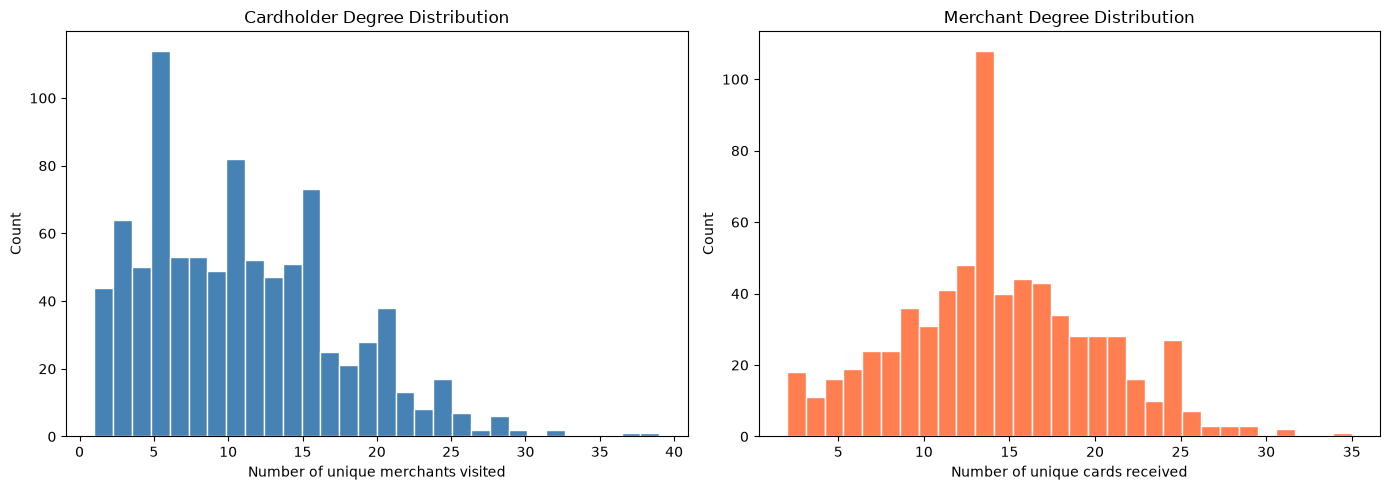

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cardholder degree distribution
axes[0].hist(ch_deg_series.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Cardholder Degree Distribution')
axes[0].set_xlabel('Number of unique merchants visited')
axes[0].set_ylabel('Count')

# Merchant degree distribution  
axes[1].hist(mer_deg_series.values, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Merchant Degree Distribution')
axes[1].set_xlabel('Number of unique cards received')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/degree_distributions.png', dpi=150)
plt.show()

In [6]:
# For each merchant, calculate:
# 1. Their degree (unique cards)
# 2. How many of their transactions were fraudulent
# 3. Their fraud rate

merchant_fraud_stats = []

for merchant in merchant_nodes:
    # Get all edges (transactions) for this merchant
    edges = G.edges(merchant, data=True)
    
    total_transactions = 0
    fraud_transactions = 0
    
    for _, _, edge_data in edges:
        total_transactions += 1
        if edge_data.get('is_fraud', 0) == 1:
            fraud_transactions += 1
    
    merchant_fraud_stats.append({
        'merchant': merchant,
        'degree': degree_dict[merchant],
        'total_transactions': total_transactions,
        'fraud_transactions': fraud_transactions,
        'fraud_rate': fraud_transactions / total_transactions if total_transactions > 0 else 0
    })

merchant_df = pd.DataFrame(merchant_fraud_stats)

print("=== HIGH FRAUD RATE MERCHANTS ===")
print(merchant_df[merchant_df['fraud_rate'] > 0].sort_values(
    'fraud_rate', ascending=False
).head(10))

=== HIGH FRAUD RATE MERCHANTS ===
                                          merchant  degree  \
321  merchant_fraud_Stokes, Christiansen and Sipes       5   
608                  merchant_fraud_Mosciski Group       6   
341                  merchant_fraud_Block-Parisian       7   
146                   merchant_fraud_Ankunding LLC       7   
558                 merchant_fraud_Wisozk and Sons       9   
49                      merchant_fraud_Goyette Inc      11   
47                    merchant_fraud_Ruecker Group      11   
287                   merchant_fraud_Padberg-Welch      24   
439                merchant_fraud_Schmidt and Sons      12   
58                  merchant_fraud_Corwin-Gorczany      13   

     total_transactions  fraud_transactions  fraud_rate  
321                   5                   1    0.200000  
608                   6                   1    0.166667  
341                   7                   1    0.142857  
146                   7                   1    0.14

#### Formalizing the thesis connection

In [ ]:
# For each merchant I will check if their cardholder neighbourhood
# forms an independent set (no two cardholders share other merchants

def neighbourhood_independence_ratio(G, merchant, cardholder_nodes):
    """
    Measures how 'independent' a merchant's cardholder neighbourhood is.

    An independent set means no two neighbours share another merchant.
    Value of 1.0 = perfect independent set = fraud signal
    Value near 0 = highly interconnected neighbours = legitimate merchant

    This connects directly to Theorem 4.2.2 in the thesis:
    fraudulent merchants dominate independent sets of victim cardholders,
    forming subgraphs isomorphic to K_{1,n}.
    """

    neighbours = [n for n in G.neighbors(merchant) if n in cardholder_nodes]

    if len(neighbours) < 2:
        return 1.0 # Single neighbour is trivially independent
    
    # Count shared merchant connections between neighbour pairs

    shared_connections = 0
    total_pairs = 0

    